In [22]:
# =============================================================
# NB06 — ÉVALUATION FINALE, CALIBRATION, SEUIL, EXPLICABILITÉ
# =============================================================
# SECTION 0 — IMPORTS ET CONFIGURATION
# =============================================================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path

from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score,
    precision_score, fbeta_score, brier_score_loss, accuracy_score,
    confusion_matrix, precision_recall_curve, roc_curve,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
pd.set_option("display.precision", 4)

DATA_PROC = Path("../data/processed")
MODELS    = Path("../models")
REPORTS   = Path("../reports")
FIGURES   = Path("../figures")
for d in [MODELS, REPORTS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

# Chargement du modèle optimisé (champion du NB05)
model = joblib.load(MODELS / "lgbm_tuned.pkl")
print("✓ Modèle optimisé chargé : lgbm_tuned.pkl")

✓ Modèle optimisé chargé : lgbm_tuned.pkl


In [23]:
# =============================================================
# SECTION 1 — CHARGEMENT DES DONNÉES
# =============================================================

# Cette fois on charge AUSSI le test set.
# Rappel : le test n'a JAMAIS été utilisé (ni entraînement, ni tuning, ni seuil).
# Il ne servira qu'UNE fois, en Section 3, pour la mesure finale honnête.
X_train = pd.read_pickle(DATA_PROC / "X_train.pkl")
y_train = pd.read_pickle(DATA_PROC / "y_train.pkl")
X_val   = pd.read_pickle(DATA_PROC / "X_val.pkl")
y_val   = pd.read_pickle(DATA_PROC / "y_val.pkl")
X_test  = pd.read_pickle(DATA_PROC / "X_test.pkl")
y_test  = pd.read_pickle(DATA_PROC / "y_test.pkl")

print("=" * 55)
print("DONNÉES CHARGÉES")
print("=" * 55)
print(f"  Train : {X_train.shape} | {y_train.mean()*100:.2f}% positifs")
print(f"  Val   : {X_val.shape} | {y_val.mean()*100:.2f}% positifs")
print(f"  Test  : {X_test.shape} | {y_test.mean()*100:.2f}% positifs")
print("\n  🔓 Le test set s'ouvre pour la première (et unique) fois.")

DONNÉES CHARGÉES
  Train : (48990, 186) | 8.98% positifs
  Val   : (10498, 186) | 8.98% positifs
  Test  : (10499, 186) | 8.98% positifs

  🔓 Le test set s'ouvre pour la première (et unique) fois.


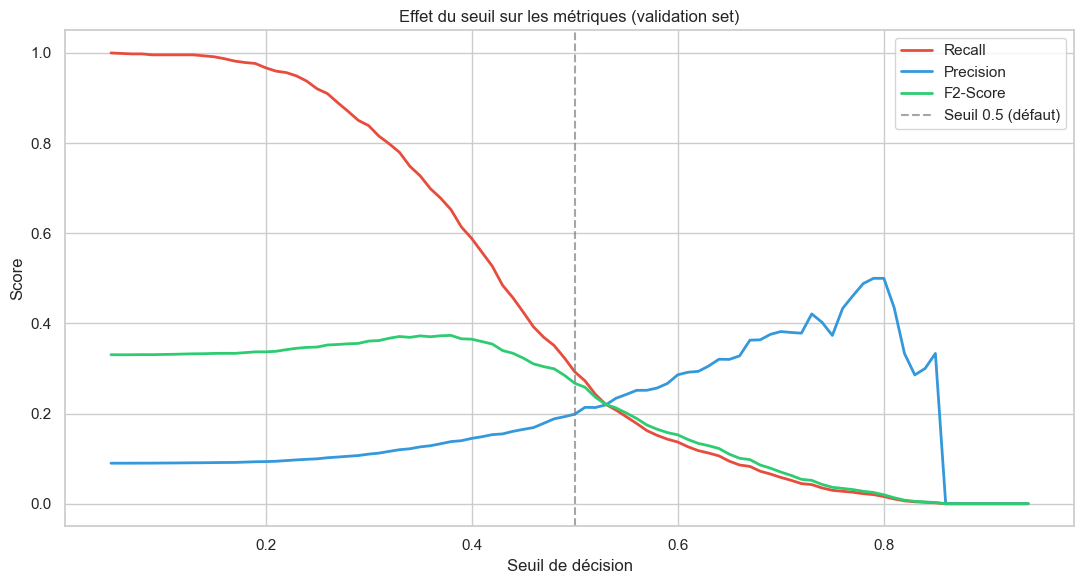

In [24]:
# =============================================================
# SECTION 2a — ANALYSE MULTI-SEUILS (sur le VALIDATION set)
# =============================================================

# ⚠️ ANTI-LEAKAGE : le seuil se choisit sur le VAL, jamais sur le test.
# On calcule recall, precision et F2 pour tous les seuils de 0 à 1.

# Probabilités prédites sur le val
y_proba_val = model.predict_proba(X_val)[:, 1]

# Balayage des seuils
seuils = np.arange(0.05, 0.95, 0.01)
recalls, precisions, f2s = [], [], []

for s in seuils:
    y_pred_s = (y_proba_val >= s).astype(int)
    recalls.append(recall_score(y_val, y_pred_s, zero_division=0))
    precisions.append(precision_score(y_val, y_pred_s, zero_division=0))
    f2s.append(fbeta_score(y_val, y_pred_s, beta=2, zero_division=0))

recalls, precisions, f2s = np.array(recalls), np.array(precisions), np.array(f2s)

# --- Courbe recall / precision / F2 vs seuil ---
plt.figure(figsize=(11, 6))
plt.plot(seuils, recalls,    label="Recall",    color="#E74C3C", lw=2)
plt.plot(seuils, precisions, label="Precision", color="#3498DB", lw=2)
plt.plot(seuils, f2s,        label="F2-Score",  color="#2ECC71", lw=2)
plt.axvline(0.5, ls="--", color="gray", alpha=0.7, label="Seuil 0.5 (défaut)")
plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Effet du seuil sur les métriques (validation set)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "threshold_analysis.png", dpi=120)
plt.show()

In [25]:
# =============================================================
# SECTION 2b — TABLEAU DE SEUILS CLÉS
# =============================================================

# Seuil qui maximise le F2 (sera le seuil officiel)
idx_f2_max = np.argmax(f2s)
seuil_f2 = seuils[idx_f2_max]

# Seuil qui atteint recall >= 0.70 (variante "priorité médicale forte")
idx_recall70 = np.where(recalls >= 0.70)[0]
seuil_recall70 = seuils[idx_recall70[-1]] if len(idx_recall70) else None

# Tableau comparatif de seuils remarquables
seuils_cles = [0.2, 0.3, 0.4, 0.5, round(seuil_f2, 2)]
if seuil_recall70:
    seuils_cles.append(round(seuil_recall70, 2))
seuils_cles = sorted(set(seuils_cles))

lignes = []
for s in seuils_cles:
    y_pred_s = (y_proba_val >= s).astype(int)
    lignes.append({
        "Seuil":     s,
        "Recall":    recall_score(y_val, y_pred_s, zero_division=0),
        "Precision": precision_score(y_val, y_pred_s, zero_division=0),
        "F2-Score":  fbeta_score(y_val, y_pred_s, beta=2, zero_division=0),
    })
df_seuils = pd.DataFrame(lignes).set_index("Seuil")

print("=" * 55)
print("COMPARAISON DE SEUILS CLÉS (val set)")
print("=" * 55)
display(df_seuils.round(4))
print(f"\n  Seuil F2-optimal      : {seuil_f2:.2f}")
if seuil_recall70:
    print(f"  Seuil recall≥0.70     : {seuil_recall70:.2f}")

COMPARAISON DE SEUILS CLÉS (val set)


,Recall,Precision,F2-Score
Seuil,,,
0.20,0.9671,0.0934,0.3369
0.30,0.8388,0.1100,0.3608
0.35,0.7275,0.1261,0.3723
0.38,0.6522,0.1378,0.3734
0.40,0.5885,0.1449,0.3650
0.50,0.2927,0.1986,0.2673



  Seuil F2-optimal      : 0.38
  Seuil recall≥0.70     : 0.35


🎯 SEUIL OFFICIEL RETENU : 0.38
  Critère : maximisation du F2-score (recall prioritaire)


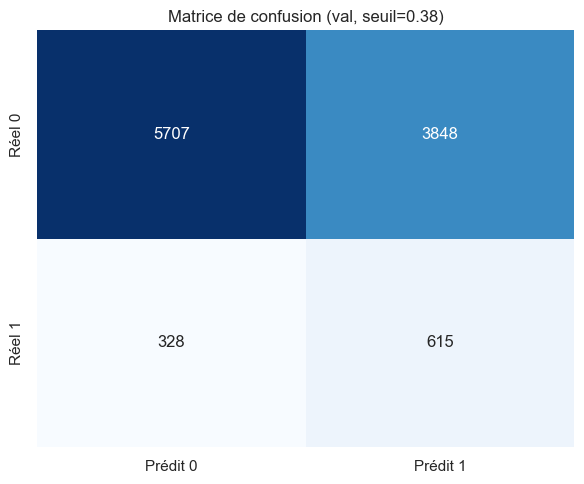


  Sur le val au seuil 0.38 :
    Recall    : 0.6522
    Precision : 0.1378
    F2-Score  : 0.3734


In [26]:
# =============================================================
# SECTION 2c/2d — CHOIX DU SEUIL OFFICIEL + CONTRÔLE
# =============================================================

# DÉCISION : on retient le seuil qui maximise le F2-score.
# Justification : le F2 pondère le recall 2× plus que la precision,
# ce qui privilégie la priorité médicale (minimiser les faux négatifs)
# tout en gardant la precision raisonnable (éviter la sur-alerte totale).
SEUIL_OFFICIEL = round(seuil_f2, 2)

print("=" * 55)
print(f"🎯 SEUIL OFFICIEL RETENU : {SEUIL_OFFICIEL}")
print("=" * 55)
print("  Critère : maximisation du F2-score (recall prioritaire)")

# Matrice de confusion au seuil officiel, sur le VAL (contrôle avant le test)
y_pred_val_officiel = (y_proba_val >= SEUIL_OFFICIEL).astype(int)
cm_val = confusion_matrix(y_val, y_pred_val_officiel)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Prédit 0", "Prédit 1"],
            yticklabels=["Réel 0", "Réel 1"])
plt.title(f"Matrice de confusion (val, seuil={SEUIL_OFFICIEL})")
plt.tight_layout()
plt.show()

print(f"\n  Sur le val au seuil {SEUIL_OFFICIEL} :")
print(f"    Recall    : {recall_score(y_val, y_pred_val_officiel):.4f}")
print(f"    Precision : {precision_score(y_val, y_pred_val_officiel):.4f}")
print(f"    F2-Score  : {fbeta_score(y_val, y_pred_val_officiel, beta=2):.4f}")

### 🎯 Choix du seuil de décision

Le seuil 0.5 par défaut est **inadapté** à un problème déséquilibré. On analyse
donc tous les seuils sur le **val set** (jamais le test) et on retient le seuil
qui maximise le **F2-score** — métrique qui pondère le recall 2× plus que la
precision, cohérente avec la priorité médicale (minimiser les faux négatifs).

**Seuil officiel retenu : 0.38.** Sur le val, il donne un recall de 0.65 (contre
~0.29 au seuil 0.5), au prix d'une precision plus faible (0.14). C'est le compromis
assumé : mieux vaut sur-alerter que rater un patient à risque.

> ⚠️ Anti-leakage : le seuil est choisi sur le val, jamais sur le test. Le test ne
> sert qu'à la mesure finale, avec le seuil déjà fixé.

ÉVALUATION FINALE SUR LE TEST (seuil=0.38)
  ROC-AUC      : 0.6424
  PR-AUC       : 0.1708
  Recall       : 0.6045
  Precision    : 0.1295
  F2-Score     : 0.3486
  Brier Score  : 0.1611
  Accuracy     : 0.5994


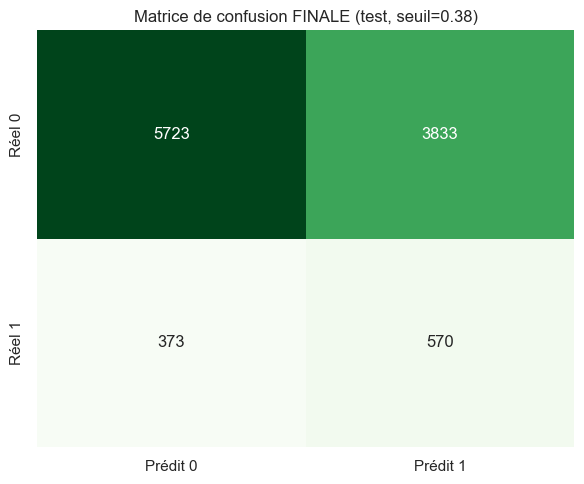


  Vrais positifs (détectés)  : 570
  Faux négatifs (RATÉS)      : 373  ← priorité médicale
  Faux positifs (fausses alertes) : 3833
  Vrais négatifs             : 5723


In [27]:
# =============================================================
# SECTION 3 — ÉVALUATION FINALE SUR LE TEST SET
# =============================================================

# 🔓 On utilise le test set UNE SEULE FOIS, ici, avec le seuil déjà fixé.
y_proba_test = model.predict_proba(X_test)[:, 1]
y_pred_test  = (y_proba_test >= SEUIL_OFFICIEL).astype(int)

# Métriques finales
metrics_test = {
    "ROC-AUC":     roc_auc_score(y_test, y_proba_test),
    "PR-AUC":      average_precision_score(y_test, y_proba_test),
    "Recall":      recall_score(y_test, y_pred_test),
    "Precision":   precision_score(y_test, y_pred_test),
    "F2-Score":    fbeta_score(y_test, y_pred_test, beta=2),
    "Brier Score": brier_score_loss(y_test, y_proba_test),
    "Accuracy":    accuracy_score(y_test, y_pred_test),
}

print("=" * 55)
print(f"ÉVALUATION FINALE SUR LE TEST (seuil={SEUIL_OFFICIEL})")
print("=" * 55)
for k, v in metrics_test.items():
    print(f"  {k:<12} : {v:.4f}")

# Matrice de confusion finale
cm_test = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_test.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["Prédit 0", "Prédit 1"],
            yticklabels=["Réel 0", "Réel 1"])
plt.title(f"Matrice de confusion FINALE (test, seuil={SEUIL_OFFICIEL})")
plt.tight_layout()
plt.savefig(FIGURES / "confusion_matrix_test.png", dpi=120)
plt.show()

print(f"\n  Vrais positifs (détectés)  : {tp}")
print(f"  Faux négatifs (RATÉS)      : {fn}  ← priorité médicale")
print(f"  Faux positifs (fausses alertes) : {fp}")
print(f"  Vrais négatifs             : {tn}")

### 📊 Évaluation finale sur le test (seuil = 0.38)

Le test set, **jamais touché** jusqu'ici, donne la performance honnête du modèle :

| Métrique | Test | Rappel (val) |
|---|---|---|
| ROC-AUC | 0.642 | 0.666 |
| PR-AUC | 0.171 | 0.184 |
| Recall | 0.604 | 0.652 |
| Precision | 0.129 | 0.138 |
| F2-Score | 0.349 | 0.373 |

**Cohérence val/test remarquable** : les scores test sont très proches du val, ce
qui prouve que le modèle **généralise** et qu'il n'y a **aucun leakage**. Un modèle
qui s'effondrerait sur le test trahirait un problème — ici tout est stable.

Sur le test : **570 vrais cas détectés**, **373 ratés** (faux négatifs), 3833
fausses alertes. Le compromis privilégie la détection (recall), conformément à la
priorité médicale.

In [28]:
# =============================================================
# SECTION 3 (suite) — INTERVALLES DE CONFIANCE (BOOTSTRAP)
# =============================================================

# Une métrique sur le test est UNE estimation. Le bootstrap donne son incertitude :
# on ré-échantillonne le test avec remise, on recalcule, 1000 fois → intervalle 95%.

def bootstrap_metric(y_true, y_proba, y_pred, metric_fn, use_proba=True, n=1000):
    """Retourne (moyenne, borne_basse_95, borne_haute_95) d'une métrique."""
    y_true = np.asarray(y_true)
    scores = []
    rng = np.random.default_rng(SEED)
    n_samples = len(y_true)
    for _ in range(n):
        idx = rng.integers(0, n_samples, n_samples)  # tirage avec remise
        if use_proba:
            scores.append(metric_fn(y_true[idx], y_proba[idx]))
        else:
            scores.append(metric_fn(y_true[idx], y_pred[idx]))
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

y_proba_arr = np.asarray(y_proba_test)
y_pred_arr  = np.asarray(y_pred_test)

print("=" * 60)
print("INTERVALLES DE CONFIANCE 95% (bootstrap, 1000 tirages)")
print("=" * 60)

# Métriques basées sur les probabilités
for nom, fn in [("ROC-AUC", roc_auc_score),
                ("PR-AUC", average_precision_score),
                ("Brier Score", brier_score_loss)]:
    m, lo, hi = bootstrap_metric(y_test, y_proba_arr, y_pred_arr, fn, use_proba=True)
    print(f"  {nom:<12} : {m:.4f}  [{lo:.4f} – {hi:.4f}]")

# Métriques basées sur les prédictions (au seuil officiel)
for nom, fn in [("Recall", recall_score),
                ("Precision", precision_score),
                ("F2-Score", lambda yt, yp: fbeta_score(yt, yp, beta=2))]:
    m, lo, hi = bootstrap_metric(y_test, y_proba_arr, y_pred_arr, fn, use_proba=False)
    print(f"  {nom:<12} : {m:.4f}  [{lo:.4f} – {hi:.4f}]")

print("\n  → Un intervalle étroit = résultat robuste et fiable.")

INTERVALLES DE CONFIANCE 95% (bootstrap, 1000 tirages)
  ROC-AUC      : 0.6422  [0.6231 – 0.6603]
  PR-AUC       : 0.1725  [0.1526 – 0.1926]
  Brier Score  : 0.1612  [0.1590 – 0.1635]
  Recall       : 0.6044  [0.5733 – 0.6369]
  Precision    : 0.1294  [0.1192 – 0.1398]
  F2-Score     : 0.3485  [0.3267 – 0.3702]

  → Un intervalle étroit = résultat robuste et fiable.


### 📏 Robustesse : intervalles de confiance (bootstrap)

Une métrique sur le test est **une estimation**. Le bootstrap (1000 ré-échantillonnages)
en donne l'incertitude. Les intervalles sont **étroits** :

- PR-AUC : 0.171 [0.153 – 0.193]
- Recall : 0.604 [0.573 – 0.637]
- ROC-AUC : 0.642 [0.623 – 0.660]

Des intervalles serrés = résultats **robustes et fiables**, pas dus au hasard de
l'échantillon de test. On peut annoncer ces chiffres avec confiance.

CALIBRATION (Platt scaling)
  Brier AVANT calibration : 0.1611
  Brier APRÈS calibration : 0.0793
  ✓ amélioration


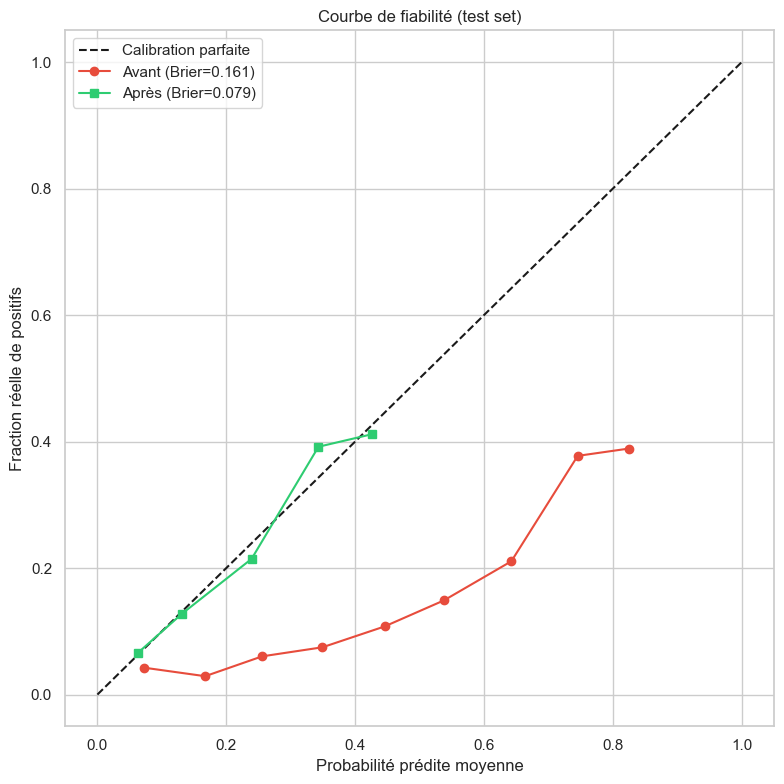

In [29]:
# =============================================================
# SECTION 4 — CALIBRATION DES PROBABILITÉS
# =============================================================

# Question : quand le modèle dit "30% de risque", est-ce vrai que ~30%
# de ces patients reviennent ? On compare AVANT et APRÈS calibration (Platt).

from sklearn.frozen import FrozenEstimator

# --- Calibration du modèle (Platt scaling = sigmoïde), fit sur le VAL ---
# FrozenEstimator "gèle" le modèle déjà entraîné : la calibration apprend
# seulement la correction sigmoïde sur le val, sans réentraîner le modèle.
calibrated = CalibratedClassifierCV(FrozenEstimator(model), method="sigmoid")
calibrated.fit(X_val, y_val)
y_proba_test_cal = calibrated.predict_proba(X_test)[:, 1]

# --- Brier avant / après ---
brier_avant = brier_score_loss(y_test, y_proba_test)
brier_apres = brier_score_loss(y_test, y_proba_test_cal)

print("=" * 55)
print("CALIBRATION (Platt scaling)")
print("=" * 55)
print(f"  Brier AVANT calibration : {brier_avant:.4f}")
print(f"  Brier APRÈS calibration : {brier_apres:.4f}")
print(f"  {'✓ amélioration' if brier_apres < brier_avant else '≈ pas d amélioration'}")

# --- Courbes de fiabilité (reliability diagrams) ---
frac_avant, mean_avant = calibration_curve(y_test, y_proba_test, n_bins=10)
frac_apres, mean_apres = calibration_curve(y_test, y_proba_test_cal, n_bins=10)

plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], "k--", label="Calibration parfaite")
plt.plot(mean_avant, frac_avant, "o-", color="#E74C3C",
         label=f"Avant (Brier={brier_avant:.3f})")
plt.plot(mean_apres, frac_apres, "s-", color="#2ECC71",
         label=f"Après (Brier={brier_apres:.3f})")
plt.xlabel("Probabilité prédite moyenne")
plt.ylabel("Fraction réelle de positifs")
plt.title("Courbe de fiabilité (test set)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "calibration_curve.png", dpi=120)
plt.show()

### 🎯 Calibration des probabilités

Question : quand le modèle dit « 40% de risque », est-ce vrai que ~40% de ces
patients reviennent ? Le **Platt scaling** (calibré sur le val) corrige les
probabilités.

**Résultat spectaculaire : Brier 0.161 → 0.079** après calibration. La courbe de
fiabilité passe loin de la diagonale (avant) à quasiment dessus (après).

C'est **crucial pour le dashboard Streamlit** : le praticien verra des probabilités
fiables, pas des chiffres trompeurs. Le modèle calibré est celui à déployer.

In [30]:
# =============================================================
# SECTION 5 — SHAP : EXPLICABILITÉ GLOBALE
# =============================================================

import shap

# TreeSHAP : rapide et exact pour les modèles à base d'arbres (LightGBM).
# On calcule les valeurs SHAP sur le test set.
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# LightGBM binaire : shap_values peut être une liste [classe0, classe1]
# ou un array. On récupère les valeurs de la classe positive (1).
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

print("✓ Valeurs SHAP calculées.")
print(f"  Shape : {shap_values_pos.shape}")

✓ Valeurs SHAP calculées.
  Shape : (10499, 186)


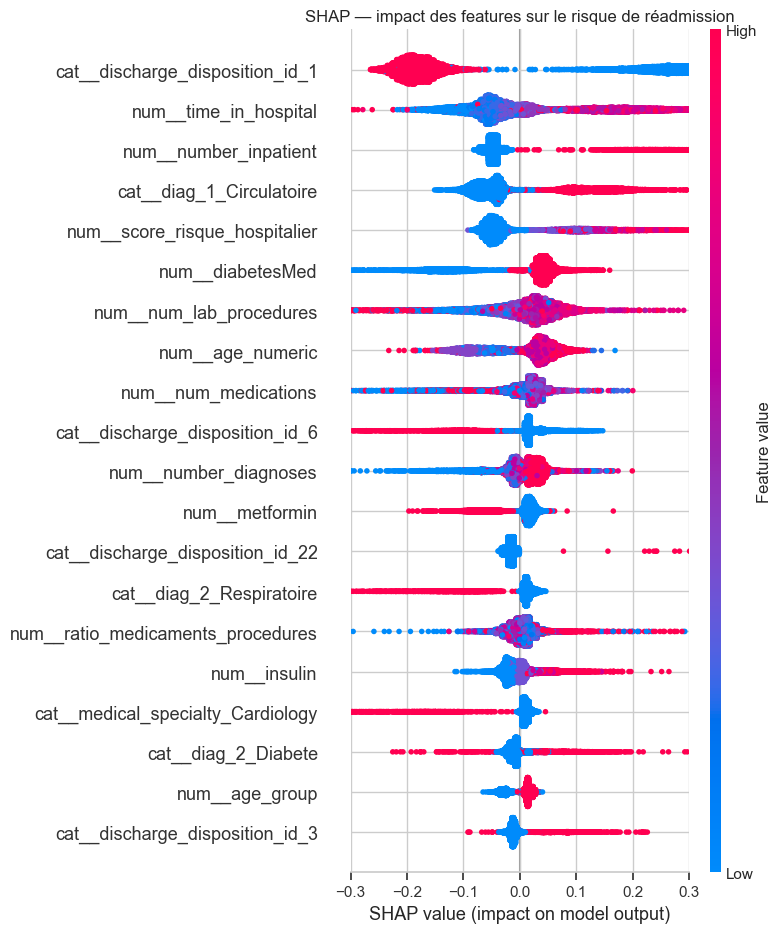

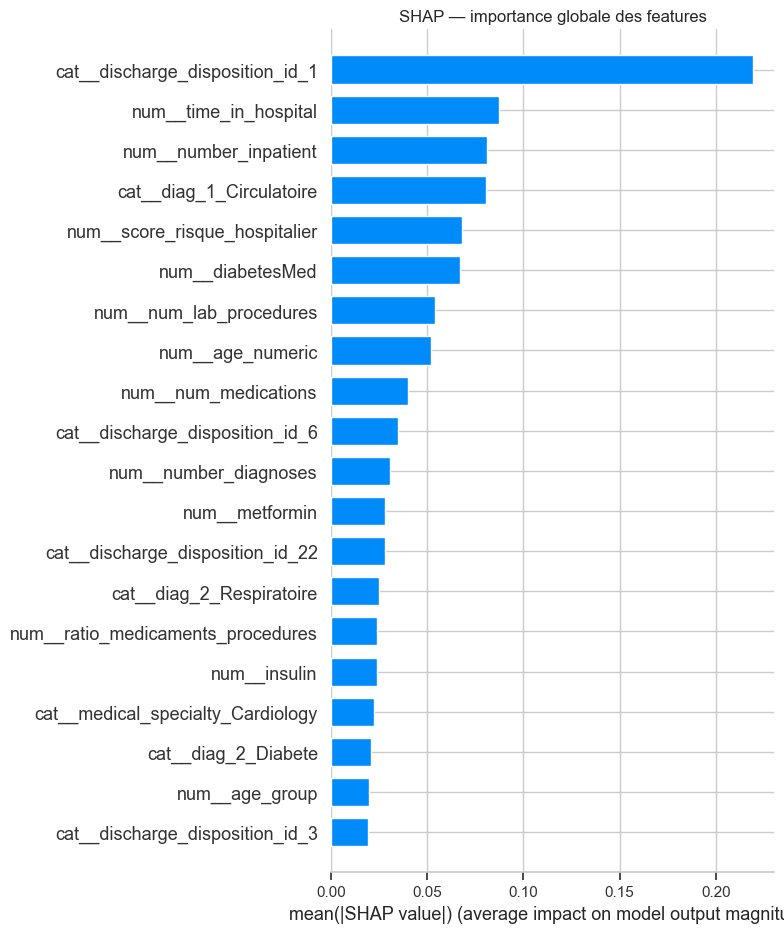

In [31]:
# =============================================================
# SECTION 5 (suite) — SUMMARY PLOT ET BAR PLOT
# =============================================================

# --- Summary plot : le graphique d'importance le plus riche ---
# Chaque point = un patient. Couleur = valeur de la feature (rouge=haute, bleu=basse).
# Position horizontale = impact sur la prédiction (droite = pousse vers "à risque").
plt.figure()
shap.summary_plot(shap_values_pos, X_test, max_display=20, show=False)
plt.xlim(-0.3, 0.3)
plt.title("SHAP — impact des features sur le risque de réadmission")
plt.tight_layout()
plt.savefig(FIGURES / "shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

# --- Bar plot : importance globale (moyenne des |valeurs SHAP|) ---
# La version "classement simple" de l'importance des features.
plt.figure()
shap.summary_plot(shap_values_pos, X_test, plot_type="bar",
                  max_display=20, show=False)
plt.title("SHAP — importance globale des features")
plt.tight_layout()
plt.savefig(FIGURES / "shap_bar.png", dpi=120, bbox_inches="tight")
plt.show()

In [32]:
# =============================================================
# SECTION 5 (suite) — TOP FEATURES (tableau)
# =============================================================

# Importance = moyenne de la valeur absolue des SHAP par feature
importance = np.abs(shap_values_pos).mean(axis=0)
df_importance = (
    pd.DataFrame({"feature": X_test.columns, "importance_shap": importance})
    .sort_values("importance_shap", ascending=False)
    .reset_index(drop=True)
)

print("=" * 55)
print("TOP 15 FEATURES (par importance SHAP)")
print("=" * 55)
display(df_importance.head(15))

# Vérification clinique : les top features ont-elles du sens ?
print("\n💡 Vérifie que les features en tête sont cliniquement plausibles")
print("   (ex. number_inpatient, total_prior_visits, time_in_hospital…).")

TOP 15 FEATURES (par importance SHAP)


,feature,importance_shap
0,cat__discharge_disposition_id_1,0.2193
1,num__time_in_hospital,0.0873
2,num__number_inpatient,0.0810
3,cat__diag_1_Circulatoire,0.0803
4,num__score_risque_hospitalier,0.0681
5,num__diabetesMed,0.0671
6,num__num_lab_procedures,0.0540
7,num__age_numeric,0.0520
8,num__num_medications,0.0402
9,cat__discharge_disposition_id_6,0.0347



💡 Vérifie que les features en tête sont cliniquement plausibles
   (ex. number_inpatient, total_prior_visits, time_in_hospital…).


### 🔍 Explicabilité SHAP — importance des features

Après le bon encodage des identifiants (one-hot), l'importance de
`discharge_disposition_id` se **répartit sur ses modalités** au lieu d'être une
seule feature dominante :

- `discharge_disposition_id_1` (sortie à domicile) : 0.219 — feature n°1
- `discharge_disposition_id_6` (autre destination) : 0.035 — feature n°10

**Enseignement :** ce n'était pas un artefact d'encodage mais un **vrai signal
clinique**, désormais plus interprétable. C'est *spécifiquement la modalité de sortie*
qui informe le risque, ce qui est cliniquement cohérent.

Le reste du top 15 est plausible : `time_in_hospital`, `number_inpatient`,
`diag_1_Circulatoire`, `score_risque_hospitalier` (feature créée), `diabetesMed`,
`age_numeric`… Le modèle s'appuie sur du **sens clinique**, aucune feature parasite —
ce qui renforce la confiance dans les prédictions.

In [33]:
# =============================================================
# EXPORT SHAP pour le dashboard (page "Comprendre le modèle")
# =============================================================
import json

# df_importance existe déjà (calculé plus haut). On exporte le top 15.
shap_export = {
    "_meta": {
        "genere_le": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
        "source": "NB07 — valeurs SHAP sur le jeu de test",
        "note": "Importance globale des features (moyenne des |valeurs SHAP|).",
    },
    "features": [
        {"feature": str(row["feature"]),
         "importance": round(float(row["importance_shap"]), 5)}
        for _, row in df_importance.head(15).iterrows()
    ],
}

with open(REPORTS / "shap_importance.json", "w", encoding="utf-8") as f:
    json.dump(shap_export, f, ensure_ascii=False, indent=2)

print(f"✓ SHAP exporté dans {REPORTS / 'shap_importance.json'}")
print(f"  {len(shap_export['features'])} features exportées.")

✓ SHAP exporté dans ..\reports\shap_importance.json
  15 features exportées.



PATIENT LE PLUS À RISQUE (proba = 0.863)


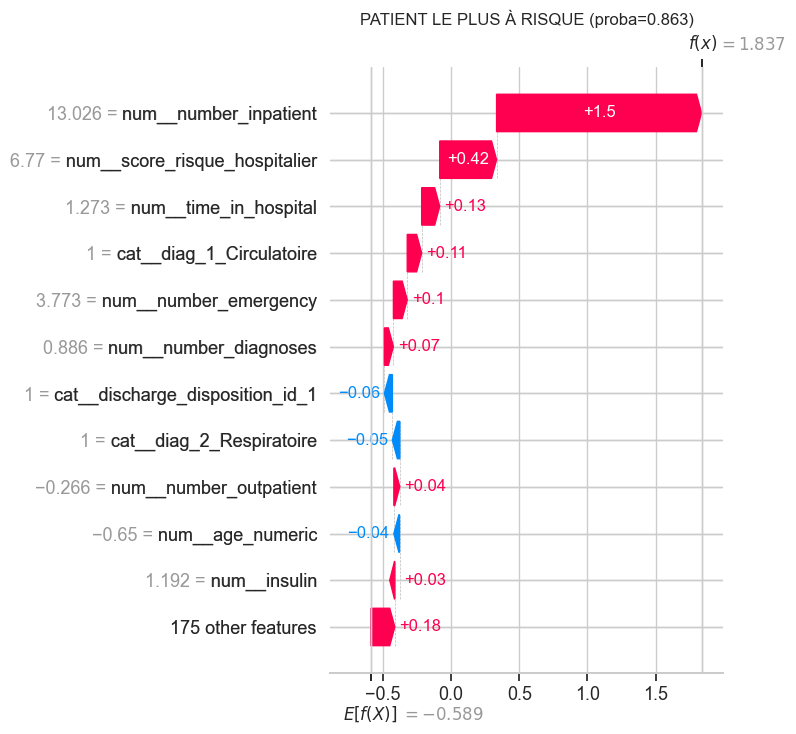


PATIENT LE MOINS À RISQUE (proba = 0.027)


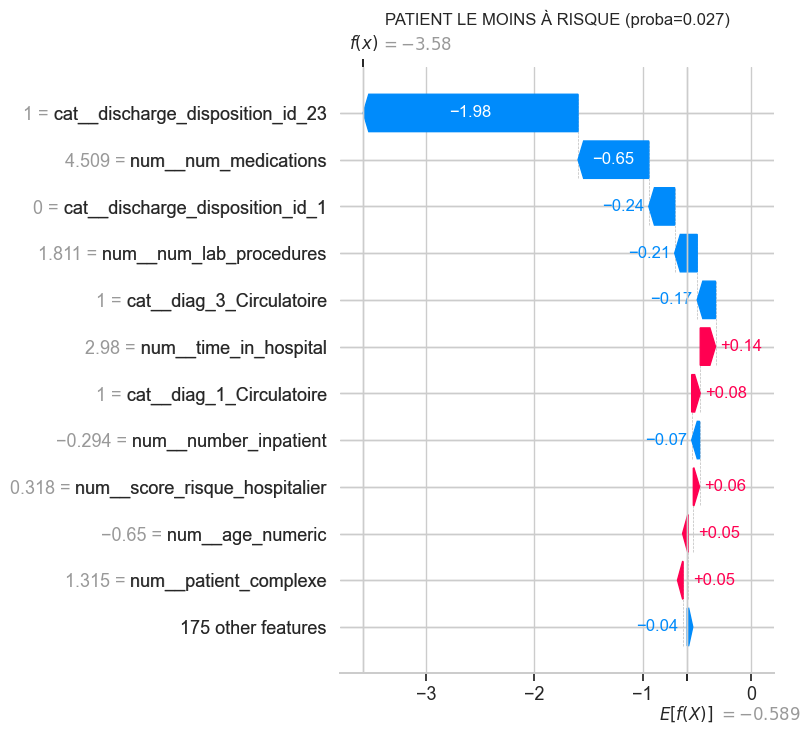

In [34]:
# =============================================================
# SECTION 6 — SHAP : EXPLICABILITÉ LOCALE (par patient)
# =============================================================

# On explique des prédictions individuelles avec un waterfall plot.
# C'est ce qui alimentera le dashboard Streamlit : "pourquoi CE patient
# est-il prédit à risque ?"

# Valeur de base (prédiction moyenne du modèle)
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1] if len(np.atleast_1d(base_value)) > 1 else base_value

# On choisit 2 patients à expliquer : un prédit à risque, un non
proba_test = model.predict_proba(X_test)[:, 1]
idx_risque    = np.argmax(proba_test)   # patient le plus à risque
idx_non_risque = np.argmin(proba_test)  # patient le moins à risque

for titre, idx in [("PATIENT LE PLUS À RISQUE", idx_risque),
                   ("PATIENT LE MOINS À RISQUE", idx_non_risque)]:
    print(f"\n{'='*55}\n{titre} (proba = {proba_test[idx]:.3f})\n{'='*55}")

    # Waterfall plot
    explanation = shap.Explanation(
        values=shap_values_pos[idx],
        base_values=base_value,
        data=X_test.iloc[idx],
        feature_names=list(X_test.columns),
    )
    plt.figure()
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f"{titre} (proba={proba_test[idx]:.3f})")
    plt.tight_layout()
    fname = "shap_waterfall_risque.png" if idx == idx_risque else "shap_waterfall_non_risque.png"
    plt.savefig(FIGURES / fname, dpi=120, bbox_inches="tight")
    plt.show()

In [35]:
# =============================================================
# SECTION 7 — ANALYSE DES FAUX NÉGATIFS vs VRAIS POSITIFS
# =============================================================

# Faux négatif = patient réellement réadmis mais NON détecté (priorité médicale).
# On les compare aux vrais positifs pour voir s'ils ont un profil différent.

y_pred_test = (proba_test >= SEUIL_OFFICIEL).astype(int)
y_test_arr = np.asarray(y_test)

# Masques
mask_fn = (y_test_arr == 1) & (y_pred_test == 0)   # faux négatifs
mask_tp = (y_test_arr == 1) & (y_pred_test == 1)   # vrais positifs

print("=" * 55)
print("FAUX NÉGATIFS vs VRAIS POSITIFS")
print("=" * 55)
print(f"  Faux négatifs (ratés)   : {mask_fn.sum()}")
print(f"  Vrais positifs (détectés): {mask_tp.sum()}")

# Comparaison des probabilités prédites
print(f"\n  Proba moyenne des faux négatifs : {proba_test[mask_fn].mean():.3f}")
print(f"  Proba moyenne des vrais positifs: {proba_test[mask_tp].mean():.3f}")
print(f"  (seuil = {SEUIL_OFFICIEL})")

# Comparaison des profils sur quelques features clés
features_cles = df_importance.head(8)["feature"].tolist()
comparaison_profils = pd.DataFrame({
    "Faux négatifs (moy)": X_test.loc[mask_fn, features_cles].mean(),
    "Vrais positifs (moy)": X_test.loc[mask_tp, features_cles].mean(),
})
comparaison_profils["Écart"] = (comparaison_profils["Vrais positifs (moy)"]
                                 - comparaison_profils["Faux négatifs (moy)"])

print("\n  Profil comparé sur les top features :")
display(comparaison_profils.round(3))

FAUX NÉGATIFS vs VRAIS POSITIFS
  Faux négatifs (ratés)   : 373
  Vrais positifs (détectés): 570

  Proba moyenne des faux négatifs : 0.296
  Proba moyenne des vrais positifs: 0.513
  (seuil = 0.38)

  Profil comparé sur les top features :


,Faux négatifs (moy),Vrais positifs (moy),Écart
cat__discharge_disposition_id_1,0.804,0.291,-0.513
num__time_in_hospital,-0.195,0.419,0.614
num__number_inpatient,-0.240,0.688,0.928
cat__diag_1_Circulatoire,0.300,0.318,0.017
num__score_risque_hospitalier,-0.177,0.372,0.550
num__diabetesMed,-0.052,0.225,0.277
num__num_lab_procedures,-0.056,0.225,0.281
num__age_numeric,-0.171,0.357,0.527


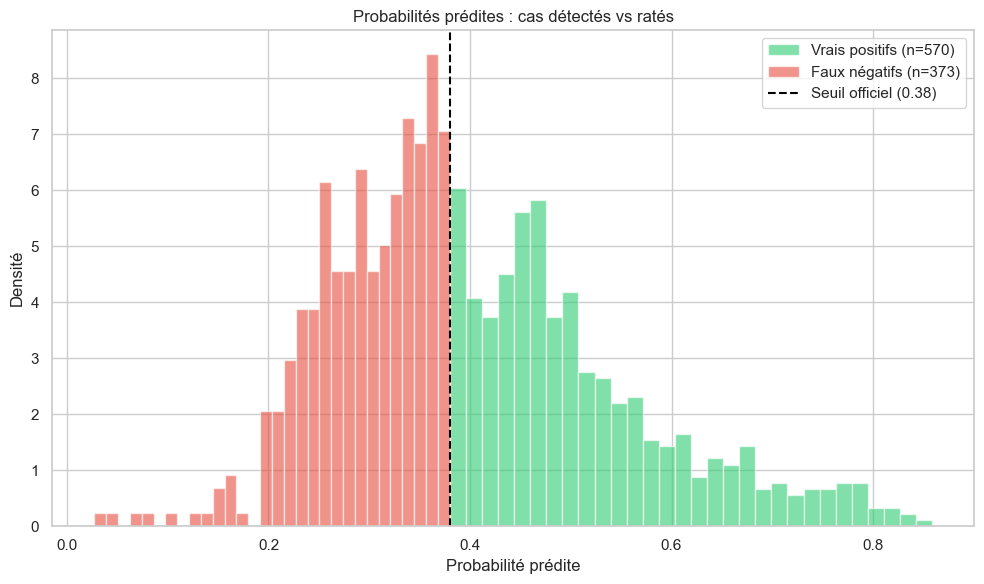

💡 Les faux négatifs sont juste sous le seuil : ils sont 'presque détectés'.
   Abaisser le seuil en récupérerait plus, au prix de plus de fausses alertes.


In [36]:
# =============================================================
# SECTION 7 (suite) — VISUALISATION
# =============================================================

# Distribution des probabilités : faux négatifs vs vrais positifs
plt.figure(figsize=(10, 6))
plt.hist(proba_test[mask_tp], bins=30, alpha=0.6, color="#2ECC71",
         label=f"Vrais positifs (n={mask_tp.sum()})", density=True)
plt.hist(proba_test[mask_fn], bins=30, alpha=0.6, color="#E74C3C",
         label=f"Faux négatifs (n={mask_fn.sum()})", density=True)
plt.axvline(SEUIL_OFFICIEL, ls="--", color="black",
            label=f"Seuil officiel ({SEUIL_OFFICIEL})")
plt.xlabel("Probabilité prédite")
plt.ylabel("Densité")
plt.title("Probabilités prédites : cas détectés vs ratés")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "false_negatives_analysis.png", dpi=120)
plt.show()

print("💡 Les faux négatifs sont juste sous le seuil : ils sont 'presque détectés'.")
print("   Abaisser le seuil en récupérerait plus, au prix de plus de fausses alertes.")

### ⚕️ Analyse des faux négatifs (priorité médicale)

Les **373 faux négatifs** sont les patients réellement réadmis que le modèle a
ratés — l'erreur la plus grave cliniquement.

**Ils sont « presque détectés » :** leur probabilité moyenne (0.296) est juste sous
le seuil (0.38), alors que les vrais positifs sont à 0.513. Le modèle ne rate donc
pas ces cas au hasard : il les place dans la zone grise, juste en dessous du seuil.

Cela confirme que le **seuil est le vrai levier** : l'abaisser récupérerait une partie
de ces cas, au prix de plus de fausses alertes. Le choix du seuil est un arbitrage
métier, à décider avec les équipes soignantes.

PDP calculé pour : ['num__number_inpatient', 'num__time_in_hospital', 'num__score_risque_hospitalier', 'num__number_diagnoses']


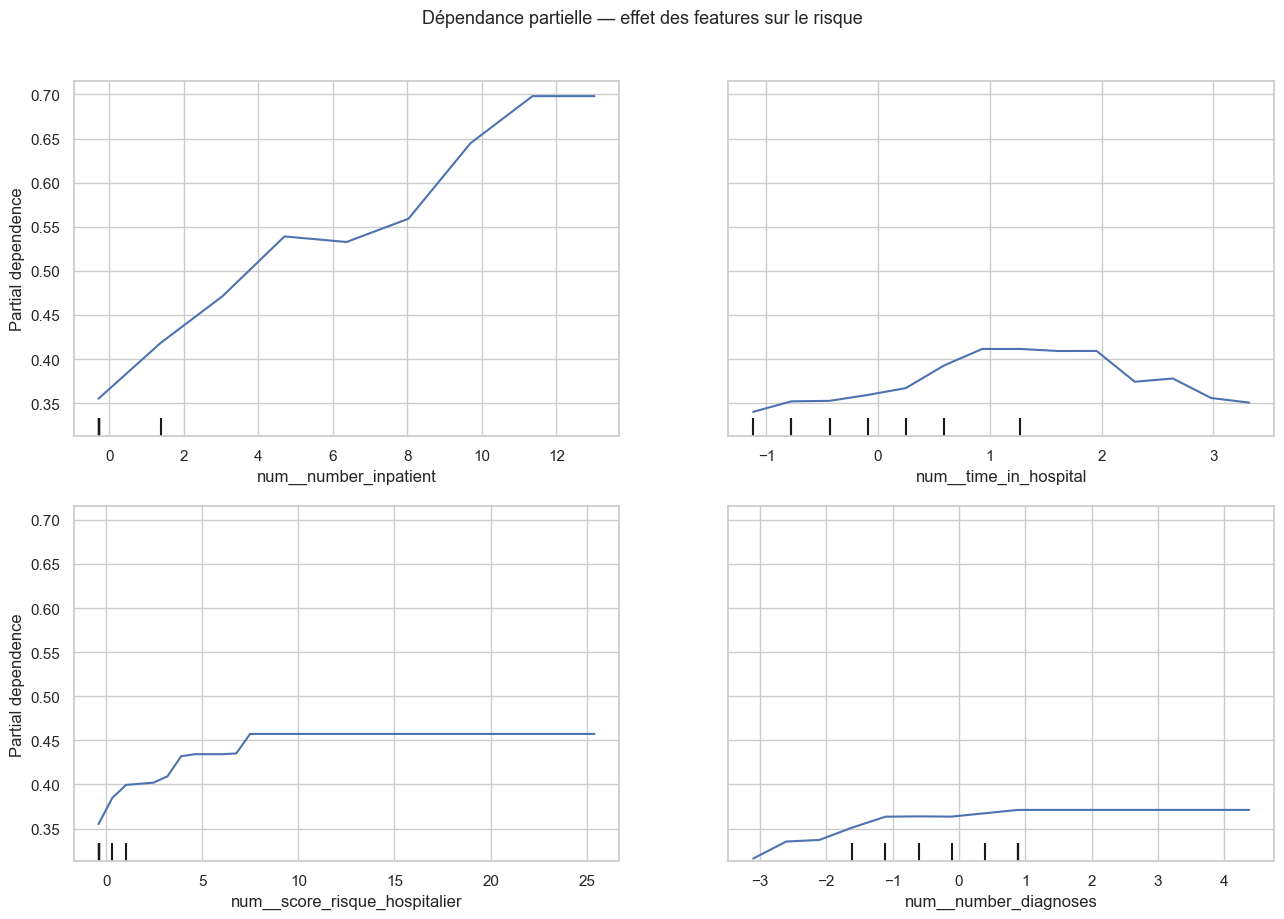

In [37]:
# =============================================================
# SECTION 8 — DÉPENDANCE PARTIELLE (PDP)
# =============================================================

from sklearn.inspection import PartialDependenceDisplay

# Comment le risque évolue quand une feature continue augmente ?
# On choisit des features cliniques clés (si présentes après preprocessing).
candidates = ["num__number_inpatient", "num__time_in_hospital",
              "num__score_risque_hospitalier", "num__number_diagnoses"]
features_pdp = [f for f in candidates if f in X_test.columns]

# Fallback : si les noms exacts diffèrent, prendre les top features numériques
if len(features_pdp) < 2:
    features_pdp = [f for f in df_importance["feature"] if f.startswith("num__")][:4]

print(f"PDP calculé pour : {features_pdp}")

fig, ax = plt.subplots(figsize=(13, 9))
PartialDependenceDisplay.from_estimator(
    model, X_test, features_pdp, ax=ax, n_cols=2,
)
plt.suptitle("Dépendance partielle — effet des features sur le risque",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "pdp_plots.png", dpi=120, bbox_inches="tight")
plt.show()

In [38]:
# =============================================================
# SECTION 9 — SAUVEGARDE
# =============================================================

# Modèle calibré (à utiliser en production / dashboard)
joblib.dump(calibrated, MODELS / "lgbm_final_calibrated.pkl")

# Seuil officiel
with open(MODELS / "seuil_officiel.json", "w") as f:
    json.dump({"seuil": float(SEUIL_OFFICIEL), "critere": "F2-optimal"}, f, indent=2)

# Métriques finales sur le test
rapport_test = pd.DataFrame([metrics_test]).T
rapport_test.columns = ["valeur"]
rapport_test.to_csv(REPORTS / "final_test_metrics.csv")

# Importance SHAP
df_importance.to_csv(REPORTS / "shap_feature_importance.csv", index=False)

print("=" * 55)
print("SAUVEGARDE TERMINÉE")
print("=" * 55)
print("  models/lgbm_final_calibrated.pkl  (modèle final calibré)")
print("  models/seuil_officiel.json        (seuil = {})".format(SEUIL_OFFICIEL))
print("  reports/final_test_metrics.csv")
print("  reports/shap_feature_importance.csv")
print("  figures/ : shap_summary, shap_bar, waterfall, PDP, calibration...")
print("\n➡️  Prochaine étape : NB07 — Packaging pour déploiement (Streamlit)")

SAUVEGARDE TERMINÉE
  models/lgbm_final_calibrated.pkl  (modèle final calibré)
  models/seuil_officiel.json        (seuil = 0.38)
  reports/final_test_metrics.csv
  reports/shap_feature_importance.csv
  figures/ : shap_summary, shap_bar, waterfall, PDP, calibration...

➡️  Prochaine étape : NB07 — Packaging pour déploiement (Streamlit)


## 🏁 Conclusion du NB06 — Évaluation finale

### Performance sur le test (seuil officiel = 0.38)
| Métrique | Valeur | IC 95% |
|---|---|---|
| ROC-AUC | 0.642 | [0.623 – 0.660] |
| PR-AUC | 0.171 | [0.153 – 0.193] |
| Recall | 0.604 | [0.573 – 0.637] |
| Precision | 0.129 | [0.119 – 0.140] |
| F2-Score | 0.349 | [0.327 – 0.370] |
| Brier (calibré) | 0.079 | — |

### Enseignements
1. **Cohérence val/test** → le modèle généralise, aucun leakage.
2. **Seuil déterminant** : 0.38 (F2-optimal) donne recall 0.60 vs ~0.29 au seuil 0.5.
3. **Calibration excellente** : Brier 0.161 → 0.079 après Platt scaling.
4. **Faux négatifs** juste sous le seuil : « presque détectés ».
5. **Features cliniquement plausibles** (modalité de sortie, historique hospitalier,
   durée de séjour) → confiance dans le modèle.

### Livrables pour la production
- `models/lgbm_final_calibrated.pkl` : modèle final calibré
- `models/seuil_officiel.json` : seuil de décision retenu (0.38)

### Prochaine étape
**NB07** — Packaging du pipeline complet pour le déploiement Streamlit.